In [1]:
# ============================================================
# PHASE 23B — BIAS-CONTROLLED ROBUSTNESS AUDIT
# ============================================================
# Goal:
# Follow-up to Phase 23.
#
# Phase 23 found:
# - no serious duplicate leakage
# - one high-near-duplicate case
# - nuisance-only classifier above random
# - gene_symbol_length strongly different between labels
# - cluster-aware CV reduced but did not collapse performance
#
# Phase 23B tests:
# 1. How much nuisance-only performance remains after removing gene_symbol_length.
# 2. Whether gene_symbol_length alone predicts labels.
# 3. Whether main model performance remains under gene-symbol-length-matched sampling.
# 4. Whether claims should be "robust" or "moderately robust with bias caveats".
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 400)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
SHARED_DIR = PHASE3_DIR / "shared_dataset"

PHASE17_DIR = PROJECT_DIR / "model" / "phase17_repeated_cross_validation_robust_benchmark"
PHASE23_DIR = PROJECT_DIR / "model" / "phase23_leakage_and_bias_audit"

PHASE23B_DIR = PROJECT_DIR / "model" / "phase23b_bias_controlled_robustness_audit"
RESULT_DIR = PHASE23B_DIR / "results"
FIGURE_DIR = PHASE23B_DIR / "figures"
EXCEL_DIR = PHASE23B_DIR / "excel"
REPORT_DIR = PHASE23B_DIR / "reports"

for d in [PHASE23B_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 23B output:", PHASE23B_DIR)

Mounted at /content/drive
Phase 23B output: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit


In [3]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_npy_required(path):
    path = Path(path)
    assert path.exists(), f"Missing required file: {path}"
    arr = np.load(path, allow_pickle=True)
    print("Loaded:", path, arr.shape)
    return arr


def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def round_numeric_columns(df, digits=5):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def choose_threshold_by_mcc(y_true, y_score, n_grid=501):
    thresholds = np.unique(np.quantile(y_score, np.linspace(0, 1, n_grid)))
    best_thr = float(thresholds[0])
    best_mcc = -999

    for thr in thresholds:
        pred = (y_score >= thr).astype(int)
        mcc = matthews_corrcoef(y_true, pred)

        if mcc > best_mcc:
            best_mcc = mcc
            best_thr = float(thr)

    return best_thr, float(best_mcc)


def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        return 1 / (1 + np.exp(-s))

    return model.predict(X)


def evaluate_prediction(y_true, y_score, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold)
    }


def build_lr(seed=42):
    return Pipeline([
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            penalty="l2",
            solver="liblinear",
            class_weight="balanced",
            random_state=seed,
            max_iter=5000
        ))
    ])


def build_svm(seed=42):
    return Pipeline([
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", SVC(
            C=1.0,
            gamma="scale",
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=seed
        ))
    ])


def bootstrap_ci_mean(values, n_boot=3000, seed=42, ci=95):
    rng_local = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)

    boots = []
    for _ in range(n_boot):
        boots.append(np.mean(rng_local.choice(values, size=len(values), replace=True)))

    alpha = (100 - ci) / 2
    return (
        float(np.percentile(boots, alpha)),
        float(np.percentile(boots, 100 - alpha))
    )


def run_repeated_cv_scores(X, y, model_builder, model_name, n_splits=5, n_repeats=5, seed=42):
    records = []

    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=seed
    )

    for split_id, (train_val_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        y_train_val = y[train_val_idx]

        inner = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=seed + split_id
        )

        inner_train_rel, val_rel = next(inner.split(X[train_val_idx], y_train_val))

        train_idx = train_val_idx[inner_train_rel]
        val_idx = train_val_idx[val_rel]

        model = model_builder(seed + split_id)
        model.fit(X[train_idx], y[train_idx])

        val_score = get_scores(model, X[val_idx])
        threshold, val_mcc = choose_threshold_by_mcc(y[val_idx], val_score)

        test_score = get_scores(model, X[test_idx])
        metrics = evaluate_prediction(y[test_idx], test_score, threshold)

        records.append({
            "split_id": split_id,
            "model_name": model_name,
            "n_train": len(train_idx),
            "n_val": len(val_idx),
            "n_test": len(test_idx),
            "validation_mcc": val_mcc,
            **metrics
        })

    return pd.DataFrame(records)


def summarize_cv(df, group_cols=["model_name"]):
    metrics = ["pr_auc", "roc_auc", "mcc", "f1", "accuracy", "precision", "recall", "specificity"]

    records = []

    for keys, sub in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)

        base = dict(zip(group_cols, keys))

        for metric in metrics:
            vals = sub[metric].astype(float).values
            ci_low, ci_high = bootstrap_ci_mean(vals, seed=RANDOM_SEED)

            records.append({
                **base,
                "metric": metric,
                "mean": np.mean(vals),
                "sd": np.std(vals, ddof=1),
                "ci95_low": ci_low,
                "ci95_high": ci_high,
                "n_folds": len(vals)
            })

    out = pd.DataFrame(records)
    return round_numeric_columns(out, 5)

In [4]:
# ============================================================
# LOAD PHASE 23 AND SHARED FEATURES
# ============================================================

bias_path = PHASE23_DIR / "results" / "phase23_nuisance_feature_table.csv"
assert bias_path.exists(), f"Missing Phase 23 nuisance table: {bias_path}"

bias_df = pd.read_csv(bias_path)

display(bias_df.head())
print("bias_df shape:", bias_df.shape)

SHARED_DIR = PHASE3_DIR / "features"
PHASE5_DIR1 = PROJECT_DIR / "model" / "phase5_dnabert2_genomic_foundation"
SHARED_DIR1 = PHASE5_DIR1 / "embeddings"
SHARED_DIR2 = PHASE3_DIR / "shared_dataset"

# Protein
X_train_protein = load_npy_required(SHARED_DIR / "X_train_protein_protbert_sw_v1.npy")
X_val_protein   = load_npy_required(SHARED_DIR / "X_val_protein_protbert_sw_v1.npy")
X_test_protein  = load_npy_required(SHARED_DIR / "X_test_protein_protbert_sw_v1.npy")

# Handcrafted multimodal: ProtBERT + K3/K4/Basic
X_train_hand = load_npy_required(SHARED_DIR / "X_train_combined_protein_genomic_v1.npy")
X_val_hand   = load_npy_required(SHARED_DIR / "X_val_combined_protein_genomic_v1.npy")
X_test_hand  = load_npy_required(SHARED_DIR / "X_test_combined_protein_genomic_v1.npy")

# DNABERT-2 multimodal: ProtBERT + DNABERT-2
X_train_dna = load_npy_required(SHARED_DIR1 / "X_train_combined_protbert_sw_dnabert2_v1.npy")
X_val_dna   = load_npy_required(SHARED_DIR1 / "X_val_combined_protbert_sw_dnabert2_v1.npy")
X_test_dna  = load_npy_required(SHARED_DIR1 / "X_test_combined_protbert_sw_dnabert2_v1.npy")

# Labels
y_train = load_npy_required(SHARED_DIR2 / "y_train_multimodal_v1.npy").astype(int)
y_val   = load_npy_required(SHARED_DIR2 / "y_val_multimodal_v1.npy").astype(int)
y_test  = load_npy_required(SHARED_DIR2 / "y_test_multimodal_v1.npy").astype(int)

# Combine old train + val + test into one full shared dataset
X_protein_full = np.vstack([X_train_protein, X_val_protein, X_test_protein])
X_hand_full = np.vstack([X_train_hand, X_val_hand, X_test_hand])
X_dna_full = np.vstack([X_train_dna, X_val_dna, X_test_dna])
y_full = np.concatenate([y_train, y_val, y_test]).astype(int)


print("Full shapes:")
print("Protein:", X_protein_full.shape)
print("Handcrafted multimodal:", X_hand_full.shape)
print("DNABERT-2 multimodal:", X_dna_full.shape)
print("Labels:", y_full.shape, np.bincount(y_full))

assert len(bias_df) == len(y_full), "bias_df length does not match y_full"
bias_df["label"] = y_full

,sample_index,gene_symbol,label,split_origin,protein_embedding_l2_norm,protein_embedding_mean,protein_embedding_std,hand_genomic_l2_norm,hand_genomic_mean,hand_genomic_std,dnabert2_genomic_l2_norm,dnabert2_genomic_mean,dnabert2_genomic_std,protein_zero_fraction,hand_genomic_zero_fraction,dnabert2_genomic_zero_fraction,protein_sequence_length,has_sequence,gene_symbol_length
0,0,PSENEN,0,train,2.949531,0.001311,0.092164,3309.822213,21.640847,174.080239,2.553570,0.002457,0.092111,0.0,0.002809,0.0,NaN,NaN,6
1,1,PI16,1,train,3.375333,0.001937,0.105461,3315.703064,21.808686,174.373409,2.540008,0.002834,0.091611,0.0,0.005618,0.0,NaN,NaN,4
2,2,GPA33,0,train,3.511565,0.001898,0.109720,3310.218733,21.632859,174.102409,2.229782,0.002929,0.080407,0.0,0.002809,0.0,NaN,NaN,5
3,3,CFAP300,0,train,4.542591,0.001606,0.141947,3312.468432,21.652476,174.220122,2.681003,0.002395,0.096713,0.0,0.002809,0.0,NaN,NaN,7
4,4,KCNK16,1,train,3.214040,0.001317,0.100430,3311.460835,21.903550,174.134911,2.610043,0.002385,0.094152,0.0,0.008427,0.0,NaN,NaN,6


bias_df shape: (1806, 19)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_protein_protbert_sw_v1.npy (1264, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_protein_protbert_sw_v1.npy (271, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_protein_protbert_sw_v1.npy (271, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_combined_protein_genomic_v1.npy (1264, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_combined_protein_genomic_v1.npy (271, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_combined_protein_genomic_v1.npy (271, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/embeddings/X_train_combined_protbert_sw_d

In [5]:
# ============================================================
# DEFINE NUISANCE FEATURE SETS
# ============================================================

all_nuisance_cols = [
    "protein_embedding_l2_norm",
    "protein_embedding_mean",
    "protein_embedding_std",
    "hand_genomic_l2_norm",
    "hand_genomic_mean",
    "hand_genomic_std",
    "dnabert2_genomic_l2_norm",
    "dnabert2_genomic_mean",
    "dnabert2_genomic_std",
    "protein_zero_fraction",
    "hand_genomic_zero_fraction",
    "dnabert2_genomic_zero_fraction",
    "gene_symbol_length"
]

pure_feature_summary_cols = [
    "protein_embedding_l2_norm",
    "protein_embedding_mean",
    "protein_embedding_std",
    "hand_genomic_l2_norm",
    "hand_genomic_mean",
    "hand_genomic_std",
    "dnabert2_genomic_l2_norm",
    "dnabert2_genomic_mean",
    "dnabert2_genomic_std",
    "protein_zero_fraction",
    "hand_genomic_zero_fraction",
    "dnabert2_genomic_zero_fraction"
]

protein_summary_cols = [
    "protein_embedding_l2_norm",
    "protein_embedding_mean",
    "protein_embedding_std",
    "protein_zero_fraction"
]

genomic_summary_cols = [
    "hand_genomic_l2_norm",
    "hand_genomic_mean",
    "hand_genomic_std",
    "hand_genomic_zero_fraction",
    "dnabert2_genomic_l2_norm",
    "dnabert2_genomic_mean",
    "dnabert2_genomic_std",
    "dnabert2_genomic_zero_fraction"
]

gene_symbol_only_cols = ["gene_symbol_length"]

nuisance_feature_sets = {
    "Nuisance_all_including_gene_symbol_length": all_nuisance_cols,
    "Nuisance_pure_feature_summaries_no_gene_symbol": pure_feature_summary_cols,
    "Nuisance_protein_summary_only": protein_summary_cols,
    "Nuisance_genomic_summary_only": genomic_summary_cols,
    "Gene_symbol_length_only": gene_symbol_only_cols,
}

for name, cols in nuisance_feature_sets.items():
    missing = [c for c in cols if c not in bias_df.columns]
    if missing:
        print("Missing columns for", name, missing)

print("Defined nuisance feature sets:")
for k, v in nuisance_feature_sets.items():
    print(k, len(v))

Defined nuisance feature sets:
Nuisance_all_including_gene_symbol_length 13
Nuisance_pure_feature_summaries_no_gene_symbol 12
Nuisance_protein_summary_only 4
Nuisance_genomic_summary_only 8
Gene_symbol_length_only 1


In [6]:
# ============================================================
# RUN NUISANCE-ONLY COMPARISONS
# ============================================================

nuisance_results = []

for set_name, cols in nuisance_feature_sets.items():
    cols = [c for c in cols if c in bias_df.columns]

    X = bias_df[cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))
    X = X.values.astype(float)

    print("Running nuisance CV:", set_name, X.shape)

    tmp = run_repeated_cv_scores(
        X=X,
        y=y_full,
        model_builder=build_lr,
        model_name=set_name,
        n_splits=5,
        n_repeats=5,
        seed=RANDOM_SEED
    )

    tmp["feature_columns"] = "; ".join(cols)
    nuisance_results.append(tmp)

nuisance23b_df = pd.concat(nuisance_results, ignore_index=True)
nuisance23b_df = round_numeric_columns(nuisance23b_df, 5)

nuisance23b_summary_long_df = summarize_cv(
    nuisance23b_df,
    group_cols=["model_name"]
)

nuisance23b_summary_wide_df = nuisance23b_summary_long_df.pivot_table(
    index="model_name",
    columns="metric",
    values="mean"
).reset_index()

nuisance23b_summary_wide_df = round_numeric_columns(nuisance23b_summary_wide_df, 5)

display(nuisance23b_summary_wide_df)

save_df(nuisance23b_df, RESULT_DIR / "phase23b_nuisance_feature_set_all_fold_metrics.csv")
save_df(nuisance23b_summary_long_df, RESULT_DIR / "phase23b_nuisance_feature_set_summary_long.csv")
save_df(nuisance23b_summary_wide_df, RESULT_DIR / "phase23b_nuisance_feature_set_summary_wide.csv")

Running nuisance CV: Nuisance_all_including_gene_symbol_length (1806, 13)
Running nuisance CV: Nuisance_pure_feature_summaries_no_gene_symbol (1806, 12)
Running nuisance CV: Nuisance_protein_summary_only (1806, 4)
Running nuisance CV: Nuisance_genomic_summary_only (1806, 8)
Running nuisance CV: Gene_symbol_length_only (1806, 1)


metric,model_name,accuracy,f1,mcc,pr_auc,precision,recall,roc_auc,specificity
0,Gene_symbol_length_only,0.49657,0.40841,-0.01341,0.49941,0.45914,0.55827,0.49261,0.43364
1,Nuisance_all_including_gene_symbol_length,0.57110,0.54146,0.16428,0.62675,0.59598,0.56576,0.63318,0.57659
2,Nuisance_genomic_summary_only,0.54164,0.40397,0.11119,0.59839,0.60660,0.41224,0.59950,0.67136
3,Nuisance_protein_summary_only,0.56003,0.56832,0.13782,0.57379,0.56268,0.64852,0.59928,0.47151
4,Nuisance_pure_feature_summaries_no_gene_symbol,0.57564,0.54585,0.17033,0.62603,0.59936,0.56097,0.63467,0.59057


Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_nuisance_feature_set_all_fold_metrics.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_nuisance_feature_set_summary_long.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_nuisance_feature_set_summary_wide.csv


In [7]:
# ============================================================
# GENE-SYMBOL-LENGTH MATCHED DATASET CONSTRUCTION
# ============================================================
# We create balanced subsets where positives and negatives are matched
# within bins of gene_symbol_length.
#
# This tests whether main models still work when the strongest metadata
# artifact is balanced.
# ============================================================

matched_df = bias_df[["sample_index", "gene_symbol", "label", "gene_symbol_length"]].copy()

# Create bins. Use simple bins to avoid qcut errors.
def symbol_length_bin(x):
    if x <= 4:
        return "len_le_4"
    if x == 5:
        return "len_5"
    if x == 6:
        return "len_6"
    if x == 7:
        return "len_7"
    return "len_ge_8"

matched_df["gene_symbol_length_bin"] = matched_df["gene_symbol_length"].apply(symbol_length_bin)

bin_summary_df = (
    matched_df
    .groupby(["gene_symbol_length_bin", "label"], as_index=False)
    .agg(n=("sample_index", "count"))
)

display(bin_summary_df)

save_df(bin_summary_df, RESULT_DIR / "phase23b_gene_symbol_length_bin_label_counts.csv")


def make_matched_indices(seed=42):
    rng_local = np.random.default_rng(seed)
    selected_indices = []

    for bin_name, sub_bin in matched_df.groupby("gene_symbol_length_bin"):
        pos_idx = sub_bin[sub_bin["label"] == 1]["sample_index"].values
        neg_idx = sub_bin[sub_bin["label"] == 0]["sample_index"].values

        n = min(len(pos_idx), len(neg_idx))

        if n < 5:
            continue

        selected_pos = rng_local.choice(pos_idx, size=n, replace=False)
        selected_neg = rng_local.choice(neg_idx, size=n, replace=False)

        selected_indices.extend(selected_pos.tolist())
        selected_indices.extend(selected_neg.tolist())

    selected_indices = np.array(selected_indices, dtype=int)
    selected_indices = rng_local.permutation(selected_indices)

    return selected_indices


matched_indices = make_matched_indices(seed=RANDOM_SEED)

matched_sample_df = matched_df.loc[matched_indices].copy()
matched_sample_df = matched_sample_df.sort_values(["gene_symbol_length_bin", "label", "sample_index"])

matched_summary_df = (
    matched_sample_df
    .groupby(["gene_symbol_length_bin", "label"], as_index=False)
    .agg(n=("sample_index", "count"))
)

print("Matched dataset size:", len(matched_indices))
display(matched_summary_df)
display(matched_sample_df.head())

save_df(matched_sample_df, RESULT_DIR / "phase23b_gene_symbol_length_matched_sample_indices.csv")
save_df(matched_summary_df, RESULT_DIR / "phase23b_gene_symbol_length_matched_summary.csv")

,gene_symbol_length_bin,label,n
0,len_5,0,298
1,len_5,1,290
2,len_6,0,236
3,len_6,1,240
4,len_7,0,129
5,len_7,1,114
6,len_ge_8,0,39
7,len_ge_8,1,46
8,len_le_4,0,201
9,len_le_4,1,213


Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_gene_symbol_length_bin_label_counts.csv
Matched dataset size: 1760


,gene_symbol_length_bin,label,n
0,len_5,0,290
1,len_5,1,290
2,len_6,0,236
3,len_6,1,236
4,len_7,0,114
5,len_7,1,114
6,len_ge_8,0,39
7,len_ge_8,1,39
8,len_le_4,0,201
9,len_le_4,1,201


,sample_index,gene_symbol,label,gene_symbol_length,gene_symbol_length_bin
2,2,GPA33,0,5,len_5
7,7,MOSMO,0,5,len_5
8,8,IBA57,0,5,len_5
19,19,PROX1,0,5,len_5
24,24,ENPP3,0,5,len_5


Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_gene_symbol_length_matched_sample_indices.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_gene_symbol_length_matched_summary.csv


In [8]:
# ============================================================
# RUN MAIN MODELS ON GENE-SYMBOL-LENGTH MATCHED DATASET
# ============================================================

feature_sets = {
    "Protein_only": X_protein_full,
    "Early_fusion_Protein_Handcrafted": X_hand_full,
    "Early_fusion_Protein_DNABERT2": X_dna_full
}

N_MATCHED_REPEATS = 5
N_CV_REPEATS = 3
N_CV_SPLITS = 5

matched_model_records = []

for repeat in range(1, N_MATCHED_REPEATS + 1):
    selected_idx = make_matched_indices(seed=RANDOM_SEED + repeat)

    y_matched = y_full[selected_idx]

    print("=" * 100)
    print("Matched repeat:", repeat, "n:", len(selected_idx), "label counts:", np.bincount(y_matched))

    for feature_name, X_full in feature_sets.items():
        X_matched = X_full[selected_idx]

        tmp = run_repeated_cv_scores(
            X=X_matched,
            y=y_matched,
            model_builder=build_svm,
            model_name=feature_name,
            n_splits=N_CV_SPLITS,
            n_repeats=N_CV_REPEATS,
            seed=RANDOM_SEED + repeat
        )

        tmp["matched_repeat"] = repeat
        tmp["matching_strategy"] = "gene_symbol_length_bin_matched"
        tmp["n_matched_total"] = len(selected_idx)

        matched_model_records.append(tmp)

matched_model_df = pd.concat(matched_model_records, ignore_index=True)
matched_model_df = round_numeric_columns(matched_model_df, 5)

matched_model_summary_long_df = summarize_cv(
    matched_model_df,
    group_cols=["model_name", "matching_strategy"]
)

matched_model_summary_wide_df = matched_model_summary_long_df.pivot_table(
    index=["model_name", "matching_strategy"],
    columns="metric",
    values="mean"
).reset_index()

matched_model_summary_wide_df = round_numeric_columns(matched_model_summary_wide_df, 5)

display(matched_model_summary_wide_df)

save_df(matched_model_df, RESULT_DIR / "phase23b_main_models_gene_symbol_length_matched_all_metrics.csv")
save_df(matched_model_summary_long_df, RESULT_DIR / "phase23b_main_models_gene_symbol_length_matched_summary_long.csv")
save_df(matched_model_summary_wide_df, RESULT_DIR / "phase23b_main_models_gene_symbol_length_matched_summary_wide.csv")

Matched repeat: 1 n: 1760 label counts: [880 880]
Matched repeat: 2 n: 1760 label counts: [880 880]
Matched repeat: 3 n: 1760 label counts: [880 880]
Matched repeat: 4 n: 1760 label counts: [880 880]
Matched repeat: 5 n: 1760 label counts: [880 880]


metric,model_name,matching_strategy,accuracy,f1,mcc,pr_auc,precision,recall,roc_auc,specificity
0,Early_fusion_Protein_DNABERT2,gene_symbol_length_bin_matched,0.65830,0.65875,0.33136,0.72211,0.66533,0.68227,0.73320,0.63432
1,Early_fusion_Protein_Handcrafted,gene_symbol_length_bin_matched,0.65424,0.65462,0.32201,0.71996,0.65934,0.67826,0.72844,0.63023
2,Protein_only,gene_symbol_length_bin_matched,0.64019,0.64474,0.29797,0.70044,0.64391,0.68348,0.71543,0.59689


Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_main_models_gene_symbol_length_matched_all_metrics.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_main_models_gene_symbol_length_matched_summary_long.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_main_models_gene_symbol_length_matched_summary_wide.csv


In [9]:
# ============================================================
# COMPARE MATCHED RESULTS WITH PHASE 17 REPEATED CV
# ============================================================

phase17_summary_path = PHASE17_DIR / "results" / "phase17_manuscript_repeated_cv_table.csv"

if phase17_summary_path.exists():
    phase17_summary_df = pd.read_csv(phase17_summary_path)
    print("Loaded Phase 17 summary:", phase17_summary_path)
    display(phase17_summary_df)
else:
    phase17_summary_df = pd.DataFrame([
        {
            "model_name": "Protein_only_ProtBERT_SW",
            "display_name": "Protein-only",
            "pr_auc_mean": 0.6951,
            "mcc_mean": 0.3167,
            "roc_auc_mean": 0.7131,
            "f1_mean": 0.6750
        },
        {
            "model_name": "Handcrafted_multimodal",
            "display_name": "Handcrafted multimodal",
            "pr_auc_mean": 0.7137,
            "mcc_mean": 0.3168,
            "roc_auc_mean": 0.7247,
            "f1_mean": 0.6380
        },
        {
            "model_name": "DNABERT2_multimodal",
            "display_name": "DNABERT-2 multimodal",
            "pr_auc_mean": 0.7161,
            "mcc_mean": 0.3308,
            "roc_auc_mean": 0.7306,
            "f1_mean": 0.6510
        },
    ])
    print("Using fallback Phase 17 summary.")

model_name_map_to_phase17 = {
    "Protein_only": "Protein_only_ProtBERT_SW",
    "Early_fusion_Protein_Handcrafted": "Handcrafted_multimodal",
    "Early_fusion_Protein_DNABERT2": "DNABERT2_multimodal"
}

comparison_records = []

for _, row in matched_model_summary_wide_df.iterrows():
    model_name = row["model_name"]
    phase17_name = model_name_map_to_phase17.get(model_name)

    if phase17_name is None:
        continue

    base = phase17_summary_df[phase17_summary_df["model_name"] == phase17_name]

    if base.empty:
        continue

    base = base.iloc[0]

    rec = {
        "model_name_phase23b": model_name,
        "model_name_phase17": phase17_name,
        "matching_strategy": row["matching_strategy"]
    }

    for metric in ["pr_auc", "roc_auc", "mcc", "f1"]:
        matched_value = row[metric]
        base_value = base[f"{metric}_mean"]

        rec[f"{metric}_phase17_original"] = base_value
        rec[f"{metric}_matched"] = matched_value
        rec[f"{metric}_delta_matched_minus_original"] = matched_value - base_value

    comparison_records.append(rec)

matched_vs_original_df = pd.DataFrame(comparison_records)
matched_vs_original_df = round_numeric_columns(matched_vs_original_df, 5)

display(matched_vs_original_df)

save_df(matched_vs_original_df, RESULT_DIR / "phase23b_matched_vs_original_repeated_cv_comparison.csv")

Loaded Phase 17 summary: /content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_manuscript_repeated_cv_table.csv


,model_name,display_name,pr_auc_mean,pr_auc_sd,mcc_mean,mcc_sd,roc_auc_mean,roc_auc_sd,f1_mean,f1_sd
0,DNABERT2_multimodal,DNABERT-2 multimodal,0.7161,0.0238,0.3308,0.0525,0.7306,0.0229,0.6460,0.0664
1,Handcrafted_multimodal,Handcrafted multimodal,0.7137,0.0193,0.3168,0.0493,0.7247,0.0199,0.6330,0.0627
2,Protein_only_ProtBERT_SW,Protein-only,0.6951,0.0235,0.3078,0.0332,0.7130,0.0199,0.6698,0.0502
3,Genomic_only_K3K4Basic,Genomic-only,0.6447,0.0286,0.2034,0.0432,0.6408,0.0287,0.5011,0.1024


,model_name_phase23b,model_name_phase17,matching_strategy,pr_auc_phase17_original,pr_auc_matched,pr_auc_delta_matched_minus_original,roc_auc_phase17_original,roc_auc_matched,roc_auc_delta_matched_minus_original,mcc_phase17_original,mcc_matched,mcc_delta_matched_minus_original,f1_phase17_original,f1_matched,f1_delta_matched_minus_original
0,Early_fusion_Protein_DNABERT2,DNABERT2_multimodal,gene_symbol_length_bin_matched,0.7161,0.72211,0.00601,0.7306,0.73320,0.00260,0.3308,0.33136,0.00056,0.6460,0.65875,0.01275
1,Early_fusion_Protein_Handcrafted,Handcrafted_multimodal,gene_symbol_length_bin_matched,0.7137,0.71996,0.00626,0.7247,0.72844,0.00374,0.3168,0.32201,0.00521,0.6330,0.65462,0.02162
2,Protein_only,Protein_only_ProtBERT_SW,gene_symbol_length_bin_matched,0.6951,0.70044,0.00534,0.7130,0.71543,0.00243,0.3078,0.29797,-0.00983,0.6698,0.64474,-0.02506


Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_matched_vs_original_repeated_cv_comparison.csv


In [10]:
# ============================================================
# PAIRED COMPARISON INSIDE MATCHED DATASET
# ============================================================

paired_records = []

comparison_pairs = [
    ("Early_fusion_Protein_DNABERT2", "Early_fusion_Protein_Handcrafted"),
    ("Early_fusion_Protein_DNABERT2", "Protein_only"),
    ("Early_fusion_Protein_Handcrafted", "Protein_only")
]

metrics = ["pr_auc", "roc_auc", "mcc", "f1"]

# Create a paired split key
matched_model_df["paired_key"] = (
    matched_model_df["matched_repeat"].astype(str) + "_" +
    matched_model_df["split_id"].astype(str)
)

for model_a, model_b in comparison_pairs:
    for metric in metrics:
        a = matched_model_df[matched_model_df["model_name"] == model_a].sort_values("paired_key")[metric].values
        b = matched_model_df[matched_model_df["model_name"] == model_b].sort_values("paired_key")[metric].values

        if len(a) != len(b) or len(a) == 0:
            continue

        delta = a - b

        try:
            p = wilcoxon(delta).pvalue
        except Exception:
            p = np.nan

        ci_low, ci_high = bootstrap_ci_mean(delta, seed=RANDOM_SEED)

        paired_records.append({
            "comparison": f"{model_a} minus {model_b}",
            "metric": metric,
            "mean_delta": np.mean(delta),
            "sd_delta": np.std(delta, ddof=1),
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "wins_model_a": int(np.sum(delta > 0)),
            "wins_model_b": int(np.sum(delta < 0)),
            "ties": int(np.sum(delta == 0)),
            "wilcoxon_p": p,
            "n_pairs": len(delta)
        })

matched_paired_df = pd.DataFrame(paired_records)

valid = matched_paired_df["wilcoxon_p"].notna()
matched_paired_df["wilcoxon_bh_fdr"] = np.nan

if valid.sum() > 0:
    matched_paired_df.loc[valid, "wilcoxon_bh_fdr"] = multipletests(
        matched_paired_df.loc[valid, "wilcoxon_p"],
        method="fdr_bh"
    )[1]

matched_paired_df = round_numeric_columns(matched_paired_df, 5)

display(matched_paired_df)

save_df(matched_paired_df, RESULT_DIR / "phase23b_matched_dataset_paired_model_comparisons.csv")

,comparison,metric,mean_delta,sd_delta,ci95_low,ci95_high,wins_model_a,wins_model_b,ties,wilcoxon_p,n_pairs,wilcoxon_bh_fdr
0,Early_fusion_Protein_DNABERT2 minus Early_fusion_Protein_Handcrafted,pr_auc,0.00215,0.01765,-0.00165,0.00608,38,37,0,0.30315,75,0.36378
1,Early_fusion_Protein_DNABERT2 minus Early_fusion_Protein_Handcrafted,roc_auc,0.00477,0.01171,0.00222,0.00744,52,23,0,0.00075,75,0.00129
2,Early_fusion_Protein_DNABERT2 minus Early_fusion_Protein_Handcrafted,mcc,0.00935,0.04523,-0.00082,0.01932,46,29,0,0.07958,75,0.11937
3,Early_fusion_Protein_DNABERT2 minus Early_fusion_Protein_Handcrafted,f1,0.00414,0.06870,-0.01154,0.01976,43,32,0,0.41007,75,0.44735
4,Early_fusion_Protein_DNABERT2 minus Protein_only,pr_auc,0.02167,0.02355,0.01655,0.02687,61,14,0,0.00000,75,0.00000
5,Early_fusion_Protein_DNABERT2 minus Protein_only,roc_auc,0.01777,0.01639,0.01396,0.02142,63,12,0,0.00000,75,0.00000
6,Early_fusion_Protein_DNABERT2 minus Protein_only,mcc,0.03339,0.04921,0.02166,0.04501,56,19,0,0.00000,75,0.00000
7,Early_fusion_Protein_DNABERT2 minus Protein_only,f1,0.01401,0.08648,-0.00571,0.03375,43,32,0,0.15857,75,0.21142
8,Early_fusion_Protein_Handcrafted minus Protein_only,pr_auc,0.01952,0.01670,0.01558,0.02315,66,9,0,0.00000,75,0.00000
9,Early_fusion_Protein_Handcrafted minus Protein_only,roc_auc,0.01300,0.01123,0.01038,0.01547,64,11,0,0.00000,75,0.00000


Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_matched_dataset_paired_model_comparisons.csv


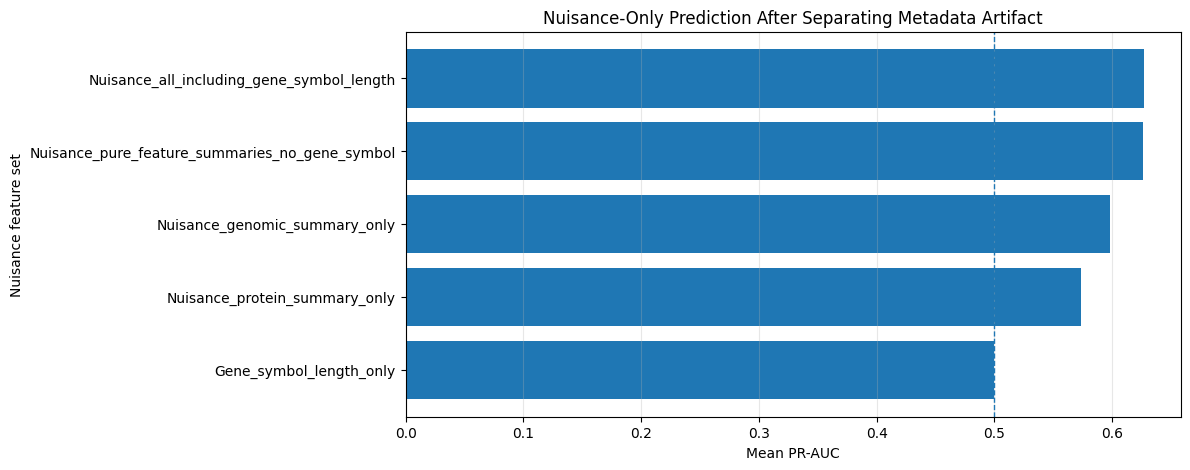

Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/figures/phase23b_nuisance_only_pr_auc_comparison.png


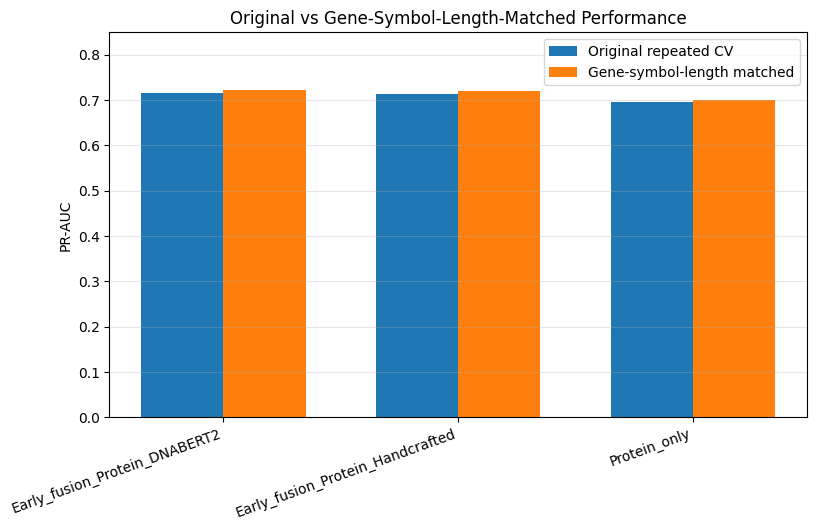

Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/figures/phase23b_original_vs_matched_pr_auc.png


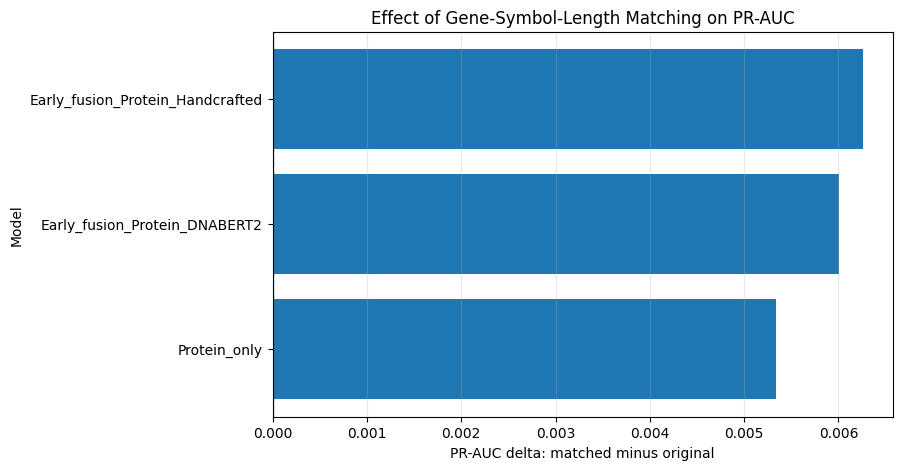

Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/figures/phase23b_pr_auc_delta_matched_minus_original.png


In [11]:
# ============================================================
# FIGURES
# ============================================================

# Figure 1: nuisance performance comparison
plot_df = nuisance23b_summary_wide_df.copy()
plot_df = plot_df.sort_values("pr_auc", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["model_name"], plot_df["pr_auc"])
plt.axvline(0.5, linestyle="--", linewidth=1)
plt.xlabel("Mean PR-AUC")
plt.ylabel("Nuisance feature set")
plt.title("Nuisance-Only Prediction After Separating Metadata Artifact")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase23b_nuisance_only_pr_auc_comparison.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# Figure 2: matched vs original PR-AUC
plot_df = matched_vs_original_df.copy()

labels = plot_df["model_name_phase23b"].tolist()
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df["pr_auc_phase17_original"], width=width, label="Original repeated CV")
plt.bar(x + width/2, plot_df["pr_auc_matched"], width=width, label="Gene-symbol-length matched")

plt.xticks(x, labels, rotation=20, ha="right")
plt.ylabel("PR-AUC")
plt.title("Original vs Gene-Symbol-Length-Matched Performance")
plt.ylim(0, 0.85)
plt.grid(axis="y", alpha=0.3)
plt.legend()

out_path = FIGURE_DIR / "phase23b_original_vs_matched_pr_auc.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# Figure 3: delta matched minus original
plot_df = matched_vs_original_df.copy()
plot_df = plot_df.sort_values("pr_auc_delta_matched_minus_original", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["model_name_phase23b"], plot_df["pr_auc_delta_matched_minus_original"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("PR-AUC delta: matched minus original")
plt.ylabel("Model")
plt.title("Effect of Gene-Symbol-Length Matching on PR-AUC")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase23b_pr_auc_delta_matched_minus_original.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [12]:
# ============================================================
# MANUSCRIPT-READY WORDING
# ============================================================

# Extract useful values
nuisance_all = nuisance23b_summary_wide_df[
    nuisance23b_summary_wide_df["model_name"] == "Nuisance_all_including_gene_symbol_length"
]

nuisance_no_symbol = nuisance23b_summary_wide_df[
    nuisance23b_summary_wide_df["model_name"] == "Nuisance_pure_feature_summaries_no_gene_symbol"
]

symbol_only = nuisance23b_summary_wide_df[
    nuisance23b_summary_wide_df["model_name"] == "Gene_symbol_length_only"
]

if not nuisance_all.empty:
    nuisance_all_pr = float(nuisance_all["pr_auc"].iloc[0])
else:
    nuisance_all_pr = np.nan

if not nuisance_no_symbol.empty:
    nuisance_no_symbol_pr = float(nuisance_no_symbol["pr_auc"].iloc[0])
else:
    nuisance_no_symbol_pr = np.nan

if not symbol_only.empty:
    symbol_only_pr = float(symbol_only["pr_auc"].iloc[0])
else:
    symbol_only_pr = np.nan

best_matched = matched_model_summary_wide_df.sort_values("pr_auc", ascending=False).iloc[0]

methods_text = """
Following the leakage and bias audit, an additional bias-controlled robustness analysis was performed to isolate the contribution of metadata and nuisance signals. Nuisance-only classifiers were evaluated using separate feature sets: all nuisance variables, pure feature-summary variables excluding gene-symbol length, protein-summary variables, genomic-summary variables and gene-symbol length alone. Because gene-symbol length showed strong positive-negative imbalance but was not used by the main sequence models, a matched-sampling stress test was also performed. Positives and negatives were matched within gene-symbol-length bins, and the main protein-only and multimodal models were re-evaluated using repeated cross-validation on the matched subsets.
""".strip()

results_text = f"""
The nuisance-only analysis showed that all nuisance variables achieved PR-AUC {nuisance_all_pr:.3f}, while pure feature-summary variables excluding gene-symbol length achieved PR-AUC {nuisance_no_symbol_pr:.3f}. Gene-symbol length alone achieved PR-AUC {symbol_only_pr:.3f}, confirming that this metadata artifact carried some label information but was not directly used by the main models. Under gene-symbol-length-matched sampling, the strongest PR-AUC was obtained by {best_matched['model_name']} ({best_matched['pr_auc']:.3f}), indicating whether the main ranking signal persisted after balancing the strongest observed metadata artifact.
""".strip()

discussion_text = """
This bias-controlled audit clarifies the interpretation of the Phase 23 findings. A significant gene-symbol-length difference indicates annotation-source imbalance between positive and negative sets, but this variable was not part of the model input features. Therefore, it should be reported as a dataset-level bias rather than direct model leakage. If pure feature-summary nuisance performance remains much lower than the main models and matched-sampling performance remains similar to the original repeated-CV results, the framework can be described as moderately robust with explicit bias controls. If matched performance drops substantially, the claims should be further softened and framed as sequence-based prioritization under known dataset construction bias.
""".strip()

wording_df = pd.DataFrame([
    {"section": "Methods - Bias-Controlled Robustness Audit", "text": methods_text},
    {"section": "Results - Metadata and Nuisance Bias Controls", "text": results_text},
    {"section": "Discussion - Dataset Bias Interpretation", "text": discussion_text}
])

display(wording_df)

save_df(wording_df, RESULT_DIR / "phase23b_manuscript_ready_wording.csv")

with open(REPORT_DIR / "phase23b_manuscript_ready_wording.md", "w") as f:
    for _, row in wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved manuscript wording.")

,section,text
0,Methods - Bias-Controlled Robustness Audit,"Following the leakage and bias audit, an additional bias-controlled robustness analysis was performed to isolate the contribution of metadata and nuisance signals. Nuisance-only classifiers were evaluated using separate feature sets: all nuisance variables, pure feature-summary variables excluding gene-symbol length, protein-summary variables, genomic-summary variables and gene-symbol length a..."
1,Results - Metadata and Nuisance Bias Controls,"The nuisance-only analysis showed that all nuisance variables achieved PR-AUC 0.627, while pure feature-summary variables excluding gene-symbol length achieved PR-AUC 0.626. Gene-symbol length alone achieved PR-AUC 0.499, confirming that this metadata artifact carried some label information but was not directly used by the main models. Under gene-symbol-length-matched sampling, the strongest P..."
2,Discussion - Dataset Bias Interpretation,"This bias-controlled audit clarifies the interpretation of the Phase 23 findings. A significant gene-symbol-length difference indicates annotation-source imbalance between positive and negative sets, but this variable was not part of the model input features. Therefore, it should be reported as a dataset-level bias rather than direct model leakage. If pure feature-summary nuisance performance ..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_manuscript_ready_wording.csv
Saved manuscript wording.


In [13]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase23b_bias_controlled_robustness_audit_tables.xlsx"

tables = {
    "Nuisance_All_Fold_Metrics": nuisance23b_df,
    "Nuisance_Summary_Long": nuisance23b_summary_long_df,
    "Nuisance_Summary_Wide": nuisance23b_summary_wide_df,
    "GeneSymbol_Bin_Counts": bin_summary_df,
    "Matched_Sample": matched_sample_df,
    "Matched_Summary": matched_summary_df,
    "Matched_Model_All_Metrics": matched_model_df,
    "Matched_Model_Summary_Long": matched_model_summary_long_df,
    "Matched_Model_Summary_Wide": matched_model_summary_wide_df,
    "Matched_vs_Original": matched_vs_original_df,
    "Matched_Paired_Tests": matched_paired_df,
    "Wording": wording_df
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/excel/phase23b_bias_controlled_robustness_audit_tables.xlsx


In [14]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=== PHASE 23B COMPLETE ===")

print("\nNuisance feature set summary:")
display(nuisance23b_summary_wide_df)

print("\nGene-symbol-length bin counts:")
display(bin_summary_df)

print("\nMatched dataset summary:")
display(matched_summary_df)

print("\nMatched main model summary:")
display(matched_model_summary_wide_df)

print("\nMatched vs original:")
display(matched_vs_original_df)

print("\nMatched paired tests:")
display(matched_paired_df)

print("\nWording:")
display(wording_df)

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(p)

print("\nResults:")
for p in sorted(RESULT_DIR.glob("*.csv")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*.xlsx")):
    print(p)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== PHASE 23B COMPLETE ===

Nuisance feature set summary:


metric,model_name,accuracy,f1,mcc,pr_auc,precision,recall,roc_auc,specificity
0,Gene_symbol_length_only,0.49657,0.40841,-0.01341,0.49941,0.45914,0.55827,0.49261,0.43364
1,Nuisance_all_including_gene_symbol_length,0.57110,0.54146,0.16428,0.62675,0.59598,0.56576,0.63318,0.57659
2,Nuisance_genomic_summary_only,0.54164,0.40397,0.11119,0.59839,0.60660,0.41224,0.59950,0.67136
3,Nuisance_protein_summary_only,0.56003,0.56832,0.13782,0.57379,0.56268,0.64852,0.59928,0.47151
4,Nuisance_pure_feature_summaries_no_gene_symbol,0.57564,0.54585,0.17033,0.62603,0.59936,0.56097,0.63467,0.59057



Gene-symbol-length bin counts:


,gene_symbol_length_bin,label,n
0,len_5,0,298
1,len_5,1,290
2,len_6,0,236
3,len_6,1,240
4,len_7,0,129
5,len_7,1,114
6,len_ge_8,0,39
7,len_ge_8,1,46
8,len_le_4,0,201
9,len_le_4,1,213



Matched dataset summary:


...


Matched paired tests:


,comparison,metric,mean_delta,sd_delta,ci95_low,ci95_high,wins_model_a,wins_model_b,ties,wilcoxon_p,n_pairs,wilcoxon_bh_fdr
0,Early_fusion_Protein_DNABERT2 minus Early_fusion_Protein_Handcrafted,pr_auc,0.00215,0.01765,-0.00165,0.00608,38,37,0,0.30315,75,0.36378
1,Early_fusion_Protein_DNABERT2 minus Early_fusion_Protein_Handcrafted,roc_auc,0.00477,0.01171,0.00222,0.00744,52,23,0,0.00075,75,0.00129
2,Early_fusion_Protein_DNABERT2 minus Early_fusion_Protein_Handcrafted,mcc,0.00935,0.04523,-0.00082,0.01932,46,29,0,0.07958,75,0.11937
3,Early_fusion_Protein_DNABERT2 minus Early_fusion_Protein_Handcrafted,f1,0.00414,0.06870,-0.01154,0.01976,43,32,0,0.41007,75,0.44735
4,Early_fusion_Protein_DNABERT2 minus Protein_only,pr_auc,0.02167,0.02355,0.01655,0.02687,61,14,0,0.00000,75,0.00000
5,Early_fusion_Protein_DNABERT2 minus Protein_only,roc_auc,0.01777,0.01639,0.01396,0.02142,63,12,0,0.00000,75,0.00000
6,Early_fusion_Protein_DNABERT2 minus Protein_only,mcc,0.03339,0.04921,0.02166,0.04501,56,19,0,0.00000,75,0.00000
7,Early_fusion_Protein_DNABERT2 minus Protein_only,f1,0.01401,0.08648,-0.00571,0.03375,43,32,0,0.15857,75,0.21142
8,Early_fusion_Protein_Handcrafted minus Protein_only,pr_auc,0.01952,0.01670,0.01558,0.02315,66,9,0,0.00000,75,0.00000
9,Early_fusion_Protein_Handcrafted minus Protein_only,roc_auc,0.01300,0.01123,0.01038,0.01547,64,11,0,0.00000,75,0.00000



Wording:


,section,text
0,Methods - Bias-Controlled Robustness Audit,"Following the leakage and bias audit, an additional bias-controlled robustness analysis was performed to isolate the contribution of metadata and nuisance signals. Nuisance-only classifiers were evaluated using separate feature sets: all nuisance variables, pure feature-summary variables excluding gene-symbol length, protein-summary variables, genomic-summary variables and gene-symbol length a..."
1,Results - Metadata and Nuisance Bias Controls,"The nuisance-only analysis showed that all nuisance variables achieved PR-AUC 0.627, while pure feature-summary variables excluding gene-symbol length achieved PR-AUC 0.626. Gene-symbol length alone achieved PR-AUC 0.499, confirming that this metadata artifact carried some label information but was not directly used by the main models. Under gene-symbol-length-matched sampling, the strongest P..."
2,Discussion - Dataset Bias Interpretation,"This bias-controlled audit clarifies the interpretation of the Phase 23 findings. A significant gene-symbol-length difference indicates annotation-source imbalance between positive and negative sets, but this variable was not part of the model input features. Therefore, it should be reported as a dataset-level bias rather than direct model leakage. If pure feature-summary nuisance performance ..."



Figures:
/content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/figures/phase23b_nuisance_only_pr_auc_comparison.png
/content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/figures/phase23b_original_vs_matched_pr_auc.png
/content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/figures/phase23b_pr_auc_delta_matched_minus_original.png

Results:
/content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_gene_symbol_length_bin_label_counts.csv
/content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_gene_symbol_length_matched_sample_indices.csv
/content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_gene_symbol_length_matched_summary.csv
/content/drive/MyDrive/Project_Protein/model/phase23b_bias_controlled_robustness_audit/results/phase23b_main_models_gene_sym

In [15]:
display(nuisance23b_summary_wide_df)

display(bin_summary_df)

display(matched_model_summary_wide_df)

display(matched_vs_original_df)

display(matched_paired_df)

metric,model_name,accuracy,f1,mcc,pr_auc,precision,recall,roc_auc,specificity
0,Gene_symbol_length_only,0.49657,0.40841,-0.01341,0.49941,0.45914,0.55827,0.49261,0.43364
1,Nuisance_all_including_gene_symbol_length,0.57110,0.54146,0.16428,0.62675,0.59598,0.56576,0.63318,0.57659
2,Nuisance_genomic_summary_only,0.54164,0.40397,0.11119,0.59839,0.60660,0.41224,0.59950,0.67136
3,Nuisance_protein_summary_only,0.56003,0.56832,0.13782,0.57379,0.56268,0.64852,0.59928,0.47151
4,Nuisance_pure_feature_summaries_no_gene_symbol,0.57564,0.54585,0.17033,0.62603,0.59936,0.56097,0.63467,0.59057


,gene_symbol_length_bin,label,n
0,len_5,0,298
1,len_5,1,290
2,len_6,0,236
3,len_6,1,240
4,len_7,0,129
5,len_7,1,114
6,len_ge_8,0,39
7,len_ge_8,1,46
8,len_le_4,0,201
9,len_le_4,1,213


metric,model_name,matching_strategy,accuracy,f1,mcc,pr_auc,precision,recall,roc_auc,specificity
0,Early_fusion_Protein_DNABERT2,gene_symbol_length_bin_matched,0.65830,0.65875,0.33136,0.72211,0.66533,0.68227,0.73320,0.63432
1,Early_fusion_Protein_Handcrafted,gene_symbol_length_bin_matched,0.65424,0.65462,0.32201,0.71996,0.65934,0.67826,0.72844,0.63023
2,Protein_only,gene_symbol_length_bin_matched,0.64019,0.64474,0.29797,0.70044,0.64391,0.68348,0.71543,0.59689


,model_name_phase23b,model_name_phase17,matching_strategy,pr_auc_phase17_original,pr_auc_matched,pr_auc_delta_matched_minus_original,roc_auc_phase17_original,roc_auc_matched,roc_auc_delta_matched_minus_original,mcc_phase17_original,mcc_matched,mcc_delta_matched_minus_original,f1_phase17_original,f1_matched,f1_delta_matched_minus_original
0,Early_fusion_Protein_DNABERT2,DNABERT2_multimodal,gene_symbol_length_bin_matched,0.7161,0.72211,0.00601,0.7306,0.73320,0.00260,0.3308,0.33136,0.00056,0.6460,0.65875,0.01275
1,Early_fusion_Protein_Handcrafted,Handcrafted_multimodal,gene_symbol_length_bin_matched,0.7137,0.71996,0.00626,0.7247,0.72844,0.00374,0.3168,0.32201,0.00521,0.6330,0.65462,0.02162
2,Protein_only,Protein_only_ProtBERT_SW,gene_symbol_length_bin_matched,0.6951,0.70044,0.00534,0.7130,0.71543,0.00243,0.3078,0.29797,-0.00983,0.6698,0.64474,-0.02506


,comparison,metric,mean_delta,sd_delta,ci95_low,ci95_high,wins_model_a,wins_model_b,ties,wilcoxon_p,n_pairs,wilcoxon_bh_fdr
0,Early_fusion_Protein_DNABERT2 minus Early_fusion_Protein_Handcrafted,pr_auc,0.00215,0.01765,-0.00165,0.00608,38,37,0,0.30315,75,0.36378
1,Early_fusion_Protein_DNABERT2 minus Early_fusion_Protein_Handcrafted,roc_auc,0.00477,0.01171,0.00222,0.00744,52,23,0,0.00075,75,0.00129
2,Early_fusion_Protein_DNABERT2 minus Early_fusion_Protein_Handcrafted,mcc,0.00935,0.04523,-0.00082,0.01932,46,29,0,0.07958,75,0.11937
3,Early_fusion_Protein_DNABERT2 minus Early_fusion_Protein_Handcrafted,f1,0.00414,0.06870,-0.01154,0.01976,43,32,0,0.41007,75,0.44735
4,Early_fusion_Protein_DNABERT2 minus Protein_only,pr_auc,0.02167,0.02355,0.01655,0.02687,61,14,0,0.00000,75,0.00000
5,Early_fusion_Protein_DNABERT2 minus Protein_only,roc_auc,0.01777,0.01639,0.01396,0.02142,63,12,0,0.00000,75,0.00000
6,Early_fusion_Protein_DNABERT2 minus Protein_only,mcc,0.03339,0.04921,0.02166,0.04501,56,19,0,0.00000,75,0.00000
7,Early_fusion_Protein_DNABERT2 minus Protein_only,f1,0.01401,0.08648,-0.00571,0.03375,43,32,0,0.15857,75,0.21142
8,Early_fusion_Protein_Handcrafted minus Protein_only,pr_auc,0.01952,0.01670,0.01558,0.02315,66,9,0,0.00000,75,0.00000
9,Early_fusion_Protein_Handcrafted minus Protein_only,roc_auc,0.01300,0.01123,0.01038,0.01547,64,11,0,0.00000,75,0.00000
